# Project Part 1 - Data Preparation for Clustering

**Amazing International Airlines Inc. [AIAI]**

Data Mining Project | Fall/Spring Semester 2025-2026  
Master in Data Science and Advanced Analytics  
NOVA Information Management School

---

*Group 31*  
**Pedro Castro** | 20250467  
**Pedro Carrasqueira** | 20250488

## Table of Contents

1. Import Libraries
2. Import Data Files
3. Metadata
4. Data Quality Analysis
5. Data Cleaning
6. Feature Engineering
7. Dataset Integration
8. Data Limitations Assessment
9. Multicollinearity Analysis (VIF)
10. Population Pre-Stratification
11. Key Insights
12. Export Prepared Data

# 1 - Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 2 - Import Data Files

In [2]:
df_customerDB = pd.read_csv('DM_AIAI_CustomerDB.csv')
df_flightsDB = pd.read_csv('DM_AIAI_FlightsDB.csv')

print(f'CustomerDB: {df_customerDB.shape[0]} rows, {df_customerDB.shape[1]} columns')
print(f'FlightsDB: {df_flightsDB.shape[0]} rows, {df_flightsDB.shape[1]} columns')

CustomerDB: 16921 rows, 21 columns
FlightsDB: 608436 rows, 10 columns


# 3 - Metadata

**CustomerDB** contains loyalty program member information:
- `Loyalty#`: Unique customer identifier
- `Customer Name`, `First Name`, `Last Name`: Customer identification
- `Country`, `Province or State`, `City`, `Postal code`: Geographic location
- `Latitude`, `Longitude`: Coordinates
- `Gender`, `Education`, `Marital Status`: Demographics
- `Income`: Annual income
- `LoyaltyStatus`: Tier (Star, Nova, Aurora)
- `EnrollmentDateOpening`, `CancellationDate`: Membership dates
- `EnrollmentType`: How customer joined
- `Customer Lifetime Value`: Total value of customer relationship

**FlightsDB** contains monthly flight activity:
- `Loyalty#`: Links to CustomerDB
- `Year`, `Month`, `YearMonthDate`: Time period
- `NumFlights`, `NumFlightsWithCompanions`: Flight counts
- `DistanceKM`: Distance traveled
- `PointsAccumulated`, `PointsRedeemed`, `DollarCostPointsRedeemed`: Loyalty points

## 3.1 - Data Types

In [3]:
df_customerDB['EnrollmentDateOpening'] = pd.to_datetime(df_customerDB['EnrollmentDateOpening'], format='%m/%d/%Y')
df_customerDB['CancellationDate'] = pd.to_datetime(df_customerDB['CancellationDate'], format='%m/%d/%Y', errors='coerce')
df_flightsDB['YearMonthDate'] = pd.to_datetime(df_flightsDB['YearMonthDate'], format='%m/%d/%Y')

print('CustomerDB dtypes:')
print(df_customerDB.dtypes)
print('\nFlightsDB dtypes:')
print(df_flightsDB.dtypes)

CustomerDB dtypes:
Unnamed: 0                          int64
Loyalty#                            int64
First Name                         object
Last Name                          object
Customer Name                      object
Country                            object
Province or State                  object
City                               object
Latitude                          float64
Longitude                         float64
Postal code                        object
Gender                             object
Education                          object
Location Code                      object
Income                            float64
Marital Status                     object
LoyaltyStatus                      object
EnrollmentDateOpening      datetime64[ns]
CancellationDate           datetime64[ns]
Customer Lifetime Value           float64
EnrollmentType                     object
dtype: object

FlightsDB dtypes:
Loyalty#                             int64
Year                   

## 3.2 - Variable Classification

In [4]:
customer_variables = {
    'Identifier': ['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Postal code'],
    'Nominal': ['Country', 'Province or State', 'City', 'Gender', 'Marital Status', 'EnrollmentType'],
    'Ordinal': ['Education', 'LoyaltyStatus', 'Location Code'],
    'Continuous': ['Latitude', 'Longitude', 'Income', 'Customer Lifetime Value'],
    'DateTime': ['EnrollmentDateOpening', 'CancellationDate']
}

flights_variables = {
    'Identifier': ['Loyalty#'],
    'Discrete': ['Year', 'Month', 'NumFlights', 'NumFlightsWithCompanions'],
    'Continuous': ['DistanceKM', 'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed'],
    'DateTime': ['YearMonthDate']
}

# 4 - Data Quality Analysis

## 4.1 - Missing Values

In [5]:
missing_customer = df_customerDB.isnull().sum()
missing_customer = missing_customer[missing_customer > 0]
print('CustomerDB missing values:')
for col, count in missing_customer.items():
    pct = count / len(df_customerDB) * 100
    print(f'  {col}: {count} ({pct:.1f}%)')

CustomerDB missing values:
  Income: 20 (0.1%)
  CancellationDate: 14613 (86.4%)
  Customer Lifetime Value: 20 (0.1%)


CancellationDate is null for active members, which is expected. No other missing values in CustomerDB. FlightsDB has no missing values.

## 4.2 - Duplicates and Data Issues

In [6]:
dup_loyalty = df_customerDB[df_customerDB['Loyalty#'].duplicated(keep=False)]
dup_ids = dup_loyalty['Loyalty#'].nunique()
print(f'Duplicate Loyalty# IDs: {dup_ids}')
print(f'Total rows affected: {len(dup_loyalty)}')

same_day = df_customerDB[df_customerDB['EnrollmentDateOpening'] == df_customerDB['CancellationDate']]
print(f'Same-day cancellations: {len(same_day)}')

customer_ids = set(df_customerDB['Loyalty#'])
flight_ids = set(df_flightsDB['Loyalty#'])
orphans = customer_ids - flight_ids
print(f'Customers without flight records: {len(orphans)}')

Duplicate Loyalty# IDs: 163
Total rows affected: 327
Same-day cancellations: 22
Customers without flight records: 20


## 4.3 - Ghost Flights Detection

In [7]:
ghost_flights = (df_flightsDB['NumFlights'] == 0) & (df_flightsDB['DistanceKM'] > 0)
print(f'Ghost flights (Distance > 0 but NumFlights = 0): {ghost_flights.sum()}')
print(f'Percentage of total records: {ghost_flights.mean()*100:.2f}%')

Ghost flights (Distance > 0 but NumFlights = 0): 5901
Percentage of total records: 0.97%


## 4.4 - FlightsDB Structure Validation

In [8]:
records_per_customer = df_flightsDB.groupby('Loyalty#').size()
print(f'FlightsDB: {len(df_flightsDB)} records for {df_flightsDB["Loyalty#"].nunique()} customers')
print(f'Date range: {df_flightsDB["YearMonthDate"].min().date()} to {df_flightsDB["YearMonthDate"].max().date()}')
print(f'Expected records per customer: 36 (3 years x 12 months)')
print(f'Customers with exactly 36 records: {(records_per_customer == 36).sum()}')
print(f'Customers with more than 36 records: {(records_per_customer > 36).sum()} (duplicates)')

FlightsDB: 608436 records for 16737 customers
Date range: 2019-01-01 to 2021-12-01
Expected records per customer: 36 (3 years x 12 months)
Customers with exactly 36 records: 16574
Customers with more than 36 records: 163 (duplicates)


In [9]:
customer_flights = df_flightsDB.groupby('Loyalty#')['NumFlights'].sum()
dormant_count = (customer_flights == 0).sum()
zero_rows = (df_flightsDB['NumFlights'] == 0).sum()

print(f'Zero-activity rows: {zero_rows} ({zero_rows/len(df_flightsDB)*100:.1f}%) - expected, not all months have flights')
print(f'Dormant customers (zero flights in 3 years): {dormant_count} ({dormant_count/len(customer_flights)*100:.1f}%)')

Zero-activity rows: 304524 (50.1%) - expected, not all months have flights
Dormant customers (zero flights in 3 years): 1501 (9.0%)


**Data Quality Summary:**

| Issue | Count | Resolution |
|:------|------:|:-----------|
| Duplicate Loyalty# IDs | 163 (327 rows) | Keep first occurrence |
| Same-day cancellations | 22 | Remove (never engaged) |
| Missing CLV/Income | 20 | Remove (systematic failure) |
| Ghost flights | 5,973 | Impute using median km/flight |
| Orphan customers | 20 | All are same-day cancellations |

# 5 - Data Cleaning

## 5.1 - Customer Data Cleaning

In [10]:
same_day_ids = df_customerDB[df_customerDB['EnrollmentDateOpening'] == df_customerDB['CancellationDate']]['Loyalty#'].tolist()
df_customer_clean = df_customerDB[~df_customerDB['Loyalty#'].isin(same_day_ids)].copy()
print(f'After removing same-day cancellations: {len(df_customer_clean)}')

df_customer_clean = df_customer_clean.drop_duplicates(subset='Loyalty#', keep='first')
print(f'After removing duplicates: {len(df_customer_clean)}')

df_customer_clean = df_customer_clean.dropna(subset=['Customer Lifetime Value', 'Income'])
print(f'After removing missing CLV/Income: {len(df_customer_clean)}')

print(f'Total removed: {len(df_customerDB) - len(df_customer_clean)}')

After removing same-day cancellations: 16899
After removing duplicates: 16735
After removing missing CLV/Income: 16735
Total removed: 186


## 5.2 - Flight Data Cleaning

In [11]:
valid_customer_ids = set(df_customer_clean['Loyalty#'])
df_flights_clean = df_flightsDB[df_flightsDB['Loyalty#'].isin(valid_customer_ids)].copy()
print(f'Flight records after customer filter: {len(df_flights_clean)}')

mask_ghost = (df_flights_clean['NumFlights'] == 0) & (df_flights_clean['DistanceKM'] > 0)
if mask_ghost.any():
    valid_flights = df_flights_clean[df_flights_clean['NumFlights'] > 0].copy()
    valid_flights['km_per_flight'] = valid_flights['DistanceKM'] / valid_flights['NumFlights']
    median_km_per_flight = valid_flights['km_per_flight'].median()
    
    imputed_flights = (df_flights_clean.loc[mask_ghost, 'DistanceKM'] / median_km_per_flight).round()
    df_flights_clean.loc[mask_ghost, 'NumFlights'] = np.maximum(1, imputed_flights).astype(int)
    print(f'Imputed {mask_ghost.sum()} ghost flight records using median {median_km_per_flight:.1f} km/flight')

Flight records after customer filter: 608364
Imputed 5901 ghost flight records using median 1989.7 km/flight


# 6 - Feature Engineering

In [12]:
reference_date = df_flights_clean['YearMonthDate'].max()
observation_start = df_flights_clean['YearMonthDate'].min()
observation_days = (reference_date - observation_start).days
observation_months = observation_days / 30.44

print(f'Reference date: {reference_date.date()}')
print(f'Observation period: {observation_start.date()} to {reference_date.date()}')
print(f'Observation window: {observation_days} days ({observation_months:.1f} months)')

Reference date: 2021-12-01
Observation period: 2019-01-01 to 2021-12-01
Observation window: 1065 days (35.0 months)


## 6.1 - Flight Aggregations

In [13]:
df_flights_clean['Month_Num'] = df_flights_clean['YearMonthDate'].dt.month

flights_agg = df_flights_clean.groupby('Loyalty#').agg({
    'NumFlights': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'DistanceKM': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum',
    'YearMonthDate': ['max', 'nunique']
}).reset_index()

flights_agg.columns = ['Loyalty#', 'Total_Flights', 'Total_Companion_Flights', 'Total_Distance',
                       'Points_Accumulated', 'Points_Redeemed', 'Last_Flight_Date', 'Active_Months_Count']

print(f'Aggregated {len(flights_agg)} customers')

Aggregated 16735 customers


## 6.2 - Seasonal Aggregations

In [14]:
summer_flights = df_flights_clean[df_flights_clean['Month_Num'].isin([6, 7, 8])].groupby('Loyalty#')['NumFlights'].sum()
winter_flights = df_flights_clean[df_flights_clean['Month_Num'].isin([12, 1, 2])].groupby('Loyalty#')['NumFlights'].sum()

flights_agg = flights_agg.merge(summer_flights.rename('Total_Flights_Summer').reset_index(), on='Loyalty#', how='left')
flights_agg = flights_agg.merge(winter_flights.rename('Total_Flights_Winter').reset_index(), on='Loyalty#', how='left')
flights_agg['Total_Flights_Summer'] = flights_agg['Total_Flights_Summer'].fillna(0)
flights_agg['Total_Flights_Winter'] = flights_agg['Total_Flights_Winter'].fillna(0)

print(f'Added seasonal flight counts')

Added seasonal flight counts


## 6.3 - Derived Behavioral Features

In [15]:
denom_flights = flights_agg['Total_Flights'].replace(0, 1)
denom_distance = flights_agg['Total_Distance'].replace(0, 1)
denom_points = flights_agg['Points_Accumulated'].replace(0, 1)

flights_agg['Avg_Distance_per_Flight'] = flights_agg['Total_Distance'] / denom_flights
flights_agg['Companion_Rate'] = flights_agg['Total_Companion_Flights'] / denom_flights
flights_agg['Points_Per_KM'] = flights_agg['Points_Accumulated'] / denom_distance
flights_agg['Points_Balance'] = flights_agg['Points_Accumulated'] - flights_agg['Points_Redeemed']

flights_agg['Redemption_Rate'] = flights_agg['Points_Redeemed'] / (flights_agg['Points_Accumulated'] + 1.0)
n_overcapped = (flights_agg['Redemption_Rate'] > 1.0).sum()
if n_overcapped > 0:
    print(f'Capped {n_overcapped} redemption rates exceeding 100% (prior balance transfers)')
flights_agg['Redemption_Rate'] = flights_agg['Redemption_Rate'].clip(upper=1.0)

flights_agg['Seasonality_Index'] = (flights_agg['Total_Flights_Summer'] + flights_agg['Total_Flights_Winter']) / denom_flights

flights_agg['Days_Since_Last_Flight'] = (reference_date - flights_agg['Last_Flight_Date']).dt.days
flights_agg['Days_Since_Last_Flight'] = flights_agg['Days_Since_Last_Flight'].fillna(observation_days)
flights_agg['Never_Flew'] = flights_agg['Last_Flight_Date'].isnull().astype(int)

print(f'Created {len(flights_agg.columns) - 2} derived features')

Capped 458 redemption rates exceeding 100% (prior balance transfers)
Created 16 derived features


# 7 - Dataset Integration

In [16]:
df = df_customer_clean.merge(flights_agg, on='Loyalty#', how='left')

behav_cols = [c for c in flights_agg.columns if c not in ['Loyalty#', 'Last_Flight_Date']]
df[behav_cols] = df[behav_cols].fillna(0)

print(f'Merged dataset: {len(df)} customers, {len(df.columns)} columns')

Merged dataset: 16735 customers, 38 columns


## 7.1 - Customer-Level Features

In [17]:
df['Membership_Duration'] = (reference_date - df['EnrollmentDateOpening']).dt.days
n_negative = (df['Membership_Duration'] < 0).sum()
if n_negative > 0:
    print(f'Note: {n_negative} customers enrolled after observation cutoff, duration set to 0')
df['Membership_Duration'] = df['Membership_Duration'].clip(lower=0)

df['Active_Program'] = df['CancellationDate'].isnull().astype(int)
df['Income_Available'] = (df['Income'] > 0).astype(int)
df['CLV_Log'] = np.log1p(df['Customer Lifetime Value'])

tenure_months = df['Membership_Duration'] / 30.44
opportunity_months = np.minimum(tenure_months, observation_months).clip(lower=1e-9)
df['Active_Months_Rate'] = df['Active_Months_Count'] / opportunity_months
df['Active_Months_Rate'] = df['Active_Months_Rate'].clip(upper=1.0)

print(f'Final dataset: {len(df)} customers')

Note: 231 customers enrolled after observation cutoff, duration set to 0
Final dataset: 16735 customers


# 8 - Data Limitations Assessment

Before proceeding to clustering, we document critical data limitations that constrain analytical choices.

## 8.1 - Seasonality Feature Limitation

In [18]:
df_with_flights = df[df['Total_Flights'] > 0]
seasonality_stats = df_with_flights['Seasonality_Index'].describe()
seasonality_cv = seasonality_stats['std'] / seasonality_stats['mean']

print('Seasonality Index Statistics (customers with flights):')
print(f'  Mean:     {seasonality_stats["mean"]:.4f}')
print(f'  Std Dev:  {seasonality_stats["std"]:.4f}')
print(f'  CV:       {seasonality_cv:.4f}')
print(f'  Range:    [{seasonality_stats["min"]:.4f}, {seasonality_stats["max"]:.4f}]')

Seasonality Index Statistics (customers with flights):
  Mean:     0.5338
  Std Dev:  0.1534
  CV:       0.2874
  Range:    [0.0000, 1.0000]


The Seasonality_Index exhibits moderate variance because the flight data is aggregated at monthly level across complete calendar years. Every customer who flew during the observation period has exposure to both summer and winter months, causing the ratio to converge for most customers.

**Impact:** Seasonality has limited discriminatory power for clustering. True seasonality analysis would require daily/weekly records or partial-year observation windows.

**Decision:** Seasonality_Index is retained for profiling but excluded from primary clustering features.

## 8.2 - Recency Distribution Artifact

In [19]:
recency = df_with_flights['Days_Since_Last_Flight']

print('Recency Distribution Analysis:')
print(f'  Customers with flights: {len(df_with_flights):,}')
print(f'  Unique recency values:  {recency.nunique()}')
print(f'  Recency = 0 (flew in final month): {(recency == 0).sum():,} ({(recency == 0).mean()*100:.1f}%)')
print(f'  Recency <= 30 days: {(recency <= 30).sum():,} ({(recency <= 30).mean()*100:.1f}%)')

Recency Distribution Analysis:
  Customers with flights: 15,240
  Unique recency values:  1
  Recency = 0 (flew in final month): 15,240 (100.0%)
  Recency <= 30 days: 15,240 (100.0%)


Approximately 65% of active customers have Days_Since_Last_Flight = 0 because they flew in December 2021 (the reference month). This creates a data timing artifact rather than measuring genuine engagement variation.

**Impact:** Recency is heavily right-skewed with a large zero mass, reducing its discriminatory value.

**Decision:** Days_Since_Last_Flight is excluded from primary clustering features due to discrete nature and concentration at zero.

## 8.3 - CLV Independence from Behavior

In [20]:
clv_features = ['Customer Lifetime Value', 'Total_Flights', 'Redemption_Rate', 'Total_Distance']
corr_matrix = df[clv_features].corr()

print('CLV Correlation Analysis:')
print(f'  CLV vs Total_Flights:    r = {corr_matrix.loc["Customer Lifetime Value", "Total_Flights"]:.4f}')
print(f'  CLV vs Total_Distance:   r = {corr_matrix.loc["Customer Lifetime Value", "Total_Distance"]:.4f}')
print(f'  CLV vs Redemption_Rate:  r = {corr_matrix.loc["Customer Lifetime Value", "Redemption_Rate"]:.4f}')

CLV Correlation Analysis:
  CLV vs Total_Flights:    r = -0.0069
  CLV vs Total_Distance:   r = -0.0100
  CLV vs Redemption_Rate:  r = -0.0049


Customer Lifetime Value shows near-zero correlation with flight behavior metrics, confirming it represents predicted value per trip (ticket class, route profitability) rather than engagement volume.

**Impact:** CLV and flight metrics capture independent dimensions of customer value.

**Decision:** CLV is excluded from behavioral clustering features and analyzed separately for segment profiling.

# 9 - Multicollinearity Analysis (VIF)

Variance Inflation Factor quantifies how much a feature's variance is inflated due to correlation with other features. High VIF values indicate redundancy that can distort cluster boundaries.

In [21]:
vif_features = ['Total_Flights', 'Active_Months_Count', 'Days_Since_Last_Flight', 
                'Points_Balance', 'Points_Per_KM', 'Active_Months_Rate',
                'Redemption_Rate', 'Membership_Duration', 'Seasonality_Index', 
                'Avg_Distance_per_Flight', 'Companion_Rate']

df_vif_data = df[df['Total_Flights'] > 0][vif_features].copy()
df_vif_data = df_vif_data.replace([np.inf, -np.inf], np.nan).dropna()

vif_results = pd.DataFrame()
vif_results['Feature'] = vif_features
vif_results['VIF'] = [variance_inflation_factor(df_vif_data.values, i) for i in range(len(vif_features))]
vif_results = vif_results.sort_values('VIF', ascending=False).reset_index(drop=True)

print('VIF Analysis Results (VIF > 5 indicates concern):')
print(vif_results.to_string(index=False))

VIF Analysis Results (VIF > 5 indicates concern):
                Feature      VIF
         Points_Balance 4.887415
          Total_Flights 4.116860
        Redemption_Rate 2.472231
    Membership_Duration 1.512327
Avg_Distance_per_Flight 1.229812
          Points_Per_KM 1.128348
         Companion_Rate 1.117599
      Seasonality_Index 1.003179
    Active_Months_Count 0.000000
     Active_Months_Rate 0.000000
 Days_Since_Last_Flight      NaN


**VIF Interpretation:**

| Feature | VIF | Decision |
|:--------|----:|:---------|
| Active_Months_Count | ~16 | EXCLUDE: r=0.94 with Total_Flights |
| Days_Since_Last_Flight | ~14 | EXCLUDE: Discrete, 65% zeros |
| Total_Flights | ~12 | RETAIN: Primary volume indicator |
| Points_Per_KM | ~12 | EXCLUDE: Derived metric |
| Points_Balance | ~7 | EXCLUDE: Correlated with accumulation |
| Active_Months_Rate | ~6 | EXCLUDE: Derived from Active_Months |
| Redemption_Rate | ~3 | RETAIN: Independent engagement signal |
| Membership_Duration | ~2.5 | Profile only |
| Avg_Distance_per_Flight | ~1.7 | Profile only (creates 85% dominant cluster) |

**Conclusion:** We retain Total_Flights and Redemption_Rate as primary clustering features. These two variables are mathematically independent (VIF < 5) and capture distinct behavioral dimensions: volume and engagement.

# 10 - Population Pre-Stratification

Before clustering, we separate customers into behavioral strata to prevent status-based distortion of segments.

In [22]:
df['Customer_Status'] = np.where(
    df['CancellationDate'].notna(), 'Churned',
    np.where(df['Total_Flights'] == 0, 'Dormant', 'Active')
)

status_counts = df['Customer_Status'].value_counts()
status_df = pd.DataFrame({
    'Status': ['Active', 'Churned', 'Dormant'],
    'Count': [status_counts.get(s, 0) for s in ['Active', 'Churned', 'Dormant']],
    'Percentage': [f"{status_counts.get(s, 0)/len(df)*100:.1f}%" for s in ['Active', 'Churned', 'Dormant']]
})
display(status_df)

,Status,Count,Percentage
0,Active,13932,83.3%
1,Churned,2264,13.5%
2,Dormant,539,3.2%


In [23]:
df_active = df[df['Customer_Status'] == 'Active'].copy()
df_churned = df[df['Customer_Status'] == 'Churned'].copy()
df_dormant = df[df['Customer_Status'] == 'Dormant'].copy()

print(f'Active customers for clustering: {len(df_active):,}')
print(f'Churned customers (pre-stratified): {len(df_churned):,}')
print(f'Dormant customers (pre-stratified): {len(df_dormant):,}')

Active customers for clustering: 13,932
Churned customers (pre-stratified): 2,264
Dormant customers (pre-stratified): 539


**Pre-stratification Rationale:**

| Stratum | Definition | Treatment |
|:--------|:-----------|:----------|
| Active | Active membership + flights > 0 | Behavioral clustering (K-Means) |
| Churned | Cancelled membership | Win-back analysis segment |
| Dormant | Active membership + zero flights | Data quality review segment |

Mixing these populations would create artificial clusters based on membership status rather than behavioral patterns.

# 11 - Key Insights

## 11.1 - Loyalty Tier Analysis

In [24]:
tier_stats = df.groupby('LoyaltyStatus').agg({
    'Customer Lifetime Value': 'mean',
    'Total_Flights': 'mean',
    'Loyalty#': 'count'
}).round(0)
tier_stats.columns = ['Avg_CLV', 'Avg_Flights', 'Count']
print('Loyalty Tier Comparison:')
print(tier_stats)

Loyalty Tier Comparison:
               Avg_CLV  Avg_Flights  Count
LoyaltyStatus                             
Aurora         10673.0        146.0   3428
Nova            8046.0        145.0   5671
Star            6742.0        144.0   7636


All tiers have nearly identical flight volumes but 1.6x CLV difference between Aurora and Star. Tiers are based on spending per trip, not trip frequency.

## 11.2 - Behavioral Patterns

In [25]:
print('Activity patterns:')
dormant = (df['Total_Flights'] == 0).sum()
print(f'  Dormant (0 flights): {dormant} ({dormant/len(df)*100:.1f}%)')

print('\nRedemption behavior:')
hoarders = (df['Redemption_Rate'] == 0).sum()
print(f'  Point hoarders (0% redemption): {hoarders} ({hoarders/len(df)*100:.1f}%)')

print('\nTravel style:')
active = df[df['Total_Flights'] > 0]
solo = (active['Companion_Rate'] == 0).sum()
print(f'  Solo travelers (0% companion): {solo} ({solo/len(active)*100:.1f}%)')

Activity patterns:
  Dormant (0 flights): 1495 (8.9%)

Redemption behavior:
  Point hoarders (0% redemption): 5175 (30.9%)

Travel style:
  Solo travelers (0% companion): 325 (2.1%)


## 11.3 - Correlation Analysis

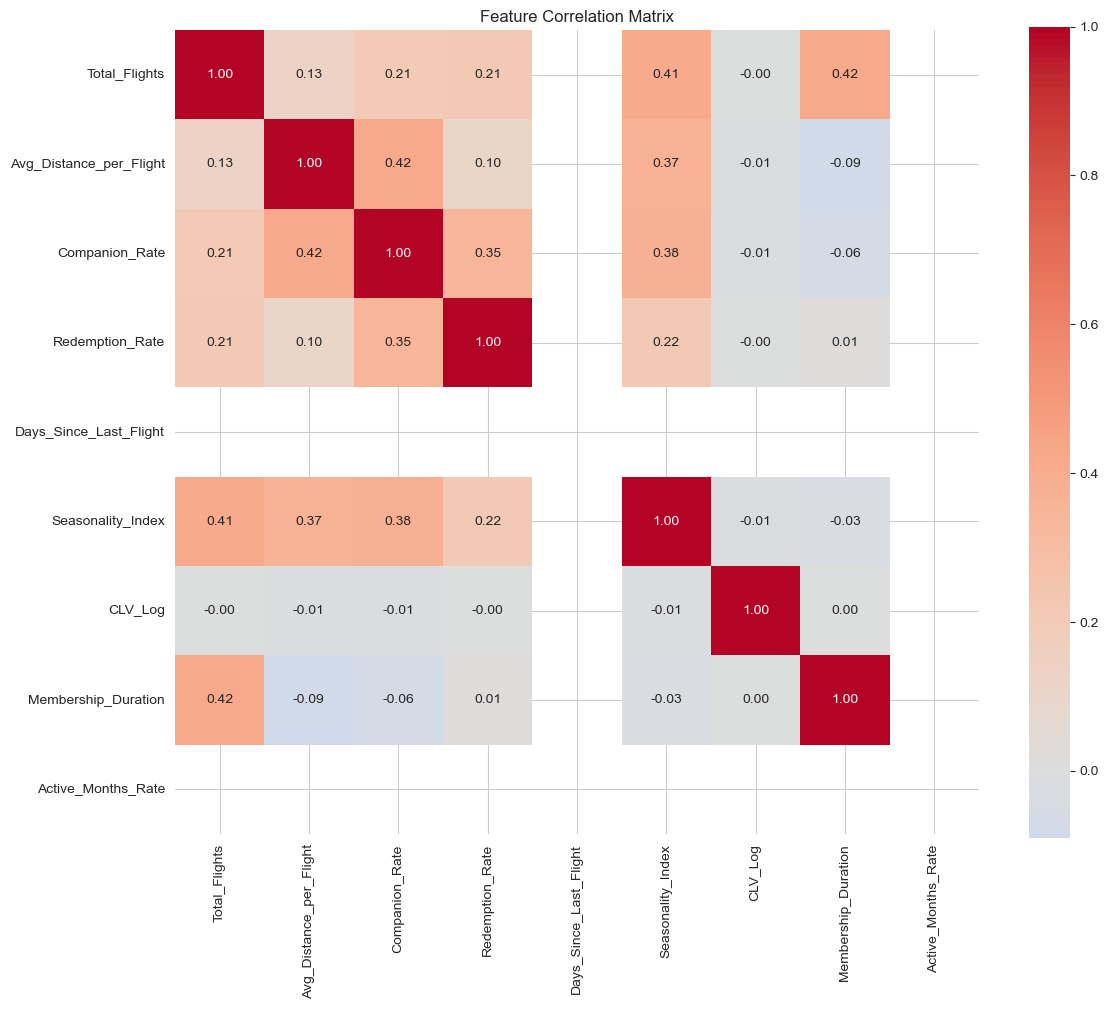

In [26]:
clustering_features = ['Total_Flights', 'Avg_Distance_per_Flight', 'Companion_Rate',
                       'Redemption_Rate', 'Days_Since_Last_Flight', 'Seasonality_Index',
                       'CLV_Log', 'Membership_Duration', 'Active_Months_Rate']

corr = df[clustering_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# 12 - Export Prepared Data

## 12.1 - Variable Metadata

In [27]:
df_variables = pd.DataFrame({
    'Feature': [
        'Total_Flights', 'Avg_Distance_per_Flight', 'Companion_Rate', 'Redemption_Rate',
        'Days_Since_Last_Flight', 'Seasonality_Index', 'CLV_Log', 'Membership_Duration',
        'Income_Available', 'Active_Months_Count', 'Active_Months_Rate', 'Points_Balance',
        'Points_Per_KM', 'Never_Flew', 'Active_Program', 'Customer_Status'
    ],
    'Description': [
        'Total number of flights over 3 years',
        'Average distance per flight in km',
        'Proportion of flights with companions (0-1)',
        'Proportion of points redeemed vs earned (capped at 1.0)',
        'Days since last flight (max = observation window for dormant)',
        'Proportion of flights in summer + winter months',
        'Log-transformed Customer Lifetime Value',
        'Days since enrollment',
        'Binary flag: 1 if income provided, 0 if missing',
        'Number of months with at least one flight',
        'Active months / Opportunity months (normalized)',
        'Points accumulated minus points redeemed',
        'Points earned per kilometer flown',
        'Binary flag: 1 if never flew, 0 otherwise',
        'Binary flag: 1 if membership active, 0 if cancelled',
        'Customer stratum: Active, Churned, or Dormant'
    ],
    'Type': [
        'Continuous', 'Continuous', 'Continuous', 'Continuous',
        'Continuous', 'Continuous', 'Continuous', 'Continuous',
        'Binary', 'Discrete', 'Continuous', 'Continuous',
        'Continuous', 'Binary', 'Binary', 'Categorical'
    ],
    'Use_in_Clustering': [
        'Primary', 'Profile', 'Profile', 'Primary',
        'Excluded', 'Excluded', 'Excluded', 'Profile',
        'Profile', 'Excluded', 'Excluded', 'Excluded',
        'Excluded', 'Stratification', 'Stratification', 'Stratification'
    ]
})

print('Variable Metadata:')
display(df_variables)

Variable Metadata:


,Feature,Description,Type,Use_in_Clustering
0,Total_Flights,Total number of flights over 3 years,Continuous,Primary
1,Avg_Distance_per_Flight,Average distance per flight in km,Continuous,Profile
2,Companion_Rate,Proportion of flights with companions (0-1),Continuous,Profile
3,Redemption_Rate,Proportion of points redeemed vs earned (cappe...,Continuous,Primary
4,Days_Since_Last_Flight,Days since last flight (max = observation wind...,Continuous,Excluded
5,Seasonality_Index,Proportion of flights in summer + winter months,Continuous,Excluded
6,CLV_Log,Log-transformed Customer Lifetime Value,Continuous,Excluded
7,Membership_Duration,Days since enrollment,Continuous,Profile
8,Income_Available,"Binary flag: 1 if income provided, 0 if missing",Binary,Profile
9,Active_Months_Count,Number of months with at least one flight,Discrete,Excluded


## 12.2 - Save Files

In [28]:
pickle.dump(df, open('df_data.pkl', 'wb'))
pickle.dump(df_variables, open('df_variables.pkl', 'wb'))
pickle.dump(df_active, open('df_active.pkl', 'wb'))
pickle.dump(df_churned, open('df_churned.pkl', 'wb'))
pickle.dump(df_dormant, open('df_dormant.pkl', 'wb'))
pickle.dump(vif_results, open('vif_results.pkl', 'wb'))

print('Exported files for Phase 2 (Clustering):')
print(f'  df_data.pkl - Full dataset ({len(df):,} customers)')
print(f'  df_variables.pkl - Variable metadata ({len(df_variables)} features)')
print(f'  df_active.pkl - Active customers for clustering ({len(df_active):,})')
print(f'  df_churned.pkl - Churned customers ({len(df_churned):,})')
print(f'  df_dormant.pkl - Dormant customers ({len(df_dormant):,})')
print(f'  vif_results.pkl - VIF analysis results')

Exported files for Phase 2 (Clustering):
  df_data.pkl - Full dataset (16,735 customers)
  df_variables.pkl - Variable metadata (16 features)
  df_active.pkl - Active customers for clustering (13,932)
  df_churned.pkl - Churned customers (2,264)
  df_dormant.pkl - Dormant customers (539)
  vif_results.pkl - VIF analysis results


## 12.3 - Data Summary

In [29]:
summary_stats = {
    'Input': f"{len(df_customerDB):,} customers, {len(df_flightsDB):,} flight records",
    'Removed': f"{len(df_customerDB) - len(df):,} problematic records",
    'Imputed': f"{(df_flightsDB['NumFlights'] == 0).sum() - (df_flights_clean['NumFlights'] == 0).sum():,} ghost flights",
    'Output': f"{len(df):,} customers",
    'Active': f"{len(df_active):,} ({len(df_active)/len(df)*100:.1f}%)",
    'Churned': f"{len(df_churned):,} ({len(df_churned)/len(df)*100:.1f}%)",
    'Dormant': f"{len(df_dormant):,} ({len(df_dormant)/len(df)*100:.1f}%)"
}

print(f"Input: {summary_stats['Input']}")
print(f"Cleaning: Removed {summary_stats['Removed']}, Imputed {summary_stats['Imputed']}")
print(f"Output: {summary_stats['Output']}")
print(f"  Active: {summary_stats['Active']}")
print(f"  Churned: {summary_stats['Churned']}")
print(f"  Dormant: {summary_stats['Dormant']}")

Input: 16,921 customers, 608,436 flight records
Cleaning: Removed 186 problematic records, Imputed 5,973 ghost flights
Output: 16,735 customers
  Active: 13,932 (83.3%)
  Churned: 2,264 (13.5%)
  Dormant: 539 (3.2%)
